---

## **DIPLOME UNIVERSITAIRE SDA**

## **ML Ops**

---

---
## **Prédiction de défaut de paiement (Loan Default)**

## **NB3_MODELISATION : Entraînement et comparaison des modèles**
---

### **Contexte**

Ce notebook fait suite au NB2_FEATURES. Il entraîne les 3 modèles imposés sur les données préparées,
compare leurs performances par cross-validation et sélectionne le meilleur modèle.

### **Données**

- **Entrées** : `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (générés par le NB2)
- **Variable cible** : `default` (binaire : 0 = pas de défaut, 1 = défaut)
- **Modèles imposés** : Decision Tree, Régression Logistique, Random Forest

---


---

### Plan du notebook

| Section | Contenu |
|---------|--------|
| 1. Configuration | Imports, chemins relatifs, seed, versions, constantes |
| 2. Chargement | Données préprocessées du NB2, quality gates |
| 3. Entraînement | 3 modèles avec Pipeline sklearn, cross-validation, chrono |
| 4. Comparaison | Tableau comparatif, visualisations des performances |
| 5. Sélection | Choix du meilleur modèle, sauvegarde |
| 6. Conclusion | Constats, limites, choix pour la suite |

---


---

### Objectif du notebook

Ce notebook est un **livrable de pipeline (modélisation comparative)**. Il couvre l'entraînement, l'évaluation et la sélection du meilleur modèle.

Il est conçu pour être :
- **reproductible** (chemins relatifs, seed fixé),
- **idempotent** (relançable sans effet de bord),
- **traçable** (quality gates go/no-go explicites, assertions),
- **orienté décisions** : chaque sortie justifie le choix du modèle retenu.

---


In [1]:
# 1.1. Imports
from pathlib import Path
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score, accuracy_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
)

print(">> 1.1. Imports : OK")


>> 1.1. Imports : OK


In [ ]:
# 1.2. Chemins relatifs (pipeline)
BASE = Path.cwd()
if not (BASE / "data").exists():
    BASE = BASE.parent
DATA_DIR = BASE / "data"
OUTPUT_DIR = BASE / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR = BASE / "model"
MODEL_DIR.mkdir(exist_ok=True)

CSV_PATH = DATA_DIR / "Loan_Data.csv"
assert CSV_PATH.exists(), f"Fichier introuvable : {CSV_PATH}"

# Convention de nommage des figures :
# OUTPUT_DIR / "NBx_nom_figure.png" (ex: NB1_eda_boxplots.png, NB2_feature_importance.png)
#
# Convention de sauvegarde des graphiques :
# plt.tight_layout()                                        # ajuster les marges
# plt.savefig(OUTPUT_DIR / "NBx_nom_figure.png", dpi=150)   # sauvegarder (dpi=150 standard projet)
# plt.show()                                                # afficher dans le notebook

print(f"Base    : {BASE}")
print(f"Fichier : {CSV_PATH}")
print(">> 1.2. Chemins : OK")

Base    : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego
Fichier : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\data\Loan_Data.csv
>> 1.2. Chemins : OK


In [3]:
# 1.3. Versions / seed
print("python  :", sys.version.split()[0])
print("pandas  :", pd.__version__)
print("numpy   :", np.__version__)
print("seaborn :", sns.__version__)

SEED = 42
np.random.seed(SEED)

# Toujours utiliser random_state=SEED dans sklearn
# Exemple : train_test_split(..., random_state=SEED)
# Exemple : DecisionTreeClassifier(random_state=SEED)

print(f"SEED    : {SEED}")
print(">> 1.3. Versions / seed : OK")

python  : 3.11.9
pandas  : 2.2.3
numpy   : 2.2.0
seaborn : 0.13.2
SEED    : 42
>> 1.3. Versions / seed : OK


In [4]:
# 1.4. Constantes du projet (heritées du NB1_EDA — ne pas modifier)

CIBLE = "default"
COLONNE_A_SUPPRIMER = ["customer_id"]
FEATURES = [
    "credit_lines_outstanding",
    "loan_amt_outstanding",
    "total_debt_outstanding",
    "income",
    "years_employed",
    "fico_score",
]
MODELES_IMPOSES = ["Decision Tree", "Regression Logistique", "Random Forest"]
TEST_SIZE = 0.2
STRATIFY = True

# Stratégie d'évaluation (métriques)
METRIC_PRIMAIRE = "f1"
METRICS_SECONDAIRES = ["recall", "precision", "roc_auc", "average_precision"]

print(">> 1.4. Constantes projet : OK")

>> 1.4. Constantes projet : OK


In [5]:
# 2.1. Chargement des données préprocessées (issues du NB2)
X_train = pd.read_csv(DATA_DIR / "X_train.csv")
X_test = pd.read_csv(DATA_DIR / "X_test.csv")
y_train = pd.read_csv(DATA_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(DATA_DIR / "y_test.csv").squeeze()

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Features : {X_train.columns.tolist()}")
print(f"Ratio défaut train : {y_train.mean():.3f}")
print(f"Ratio défaut test  : {y_test.mean():.3f}")
print(">> 2.1. Chargement : OK")


X_train : (8000, 8)
X_test  : (2000, 8)
Features : ['credit_lines_outstanding', 'loan_amt_outstanding', 'total_debt_outstanding', 'income', 'years_employed', 'fico_score', 'ratio_dette_revenu', 'ratio_dette_pret']
Ratio défaut train : 0.185
Ratio défaut test  : 0.185
>> 2.1. Chargement : OK


In [6]:
# 2.1b. Quality gates sur les données du NB2
checks = {
    "X_train lignes": (X_train.shape[0], X_train.shape[0] == 8000),
    "X_test lignes": (X_test.shape[0], X_test.shape[0] == 2000),
    "Features identiques": (X_train.columns.tolist() == X_test.columns.tolist(), True),
    "NaN X_train": (X_train.isnull().sum().sum(), X_train.isnull().sum().sum() == 0),
    "NaN X_test": (X_test.isnull().sum().sum(), X_test.isnull().sum().sum() == 0),
    "Ratio défaut train": (round(y_train.mean(), 2), abs(y_train.mean() - 0.185) < 0.01),
}

all_ok = True
for k, (valeur, condition) in checks.items():
    status = "[OK]" if condition else "[KO]"
    if not condition:
        all_ok = False
    print(f"  {status} {k}: {valeur}")

assert all_ok, "Quality gates KO — vérifier les sorties du NB2"
print(">> 2.1b. Quality gates : OK")


  [OK] X_train lignes: 8000
  [OK] X_test lignes: 2000
  [OK] Features identiques: True
  [OK] NaN X_train: 0
  [OK] NaN X_test: 0
  [OK] Ratio défaut train: 0.19
>> 2.1b. Quality gates : OK


---

### 3. Entraînement des modèles

Les 3 modèles imposés sont entraînés avec des Pipelines sklearn.
Le scaler est intégré dans le Pipeline pour la Régression Logistique (évite le data leakage).
Chaque modèle utilise `class_weight="balanced"` pour gérer le déséquilibre des classes.

---


In [7]:
# 3.1. Définition des Pipelines et cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline LR : scaler + modèle (évite le data leakage)
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
])

# Pipeline DT : pas besoin de scaler (invariant aux échelles)
pipe_dt = Pipeline([
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=SEED)),
])

# Pipeline RF : pas besoin de scaler
pipe_rf = Pipeline([
    ("clf", RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=SEED)),
])

pipelines = [
    ("Régression Logistique", pipe_lr),
    ("Decision Tree", pipe_dt),
    ("Random Forest", pipe_rf),
]

print(f"Cross-validation : {cv.n_splits} folds stratifiés")
print(f"Modèles à entraîner : {[nom for nom, _ in pipelines]}")
print(">> 3.1. Pipelines définis : OK")


Cross-validation : 5 folds stratifiés
Modèles à entraîner : ['Régression Logistique', 'Decision Tree', 'Random Forest']
>> 3.1. Pipelines définis : OK


In [8]:
# 3.2. Entraînement + mesure des performances
resultats = []

for nom, pipe in pipelines:
    t0 = time.time()
    pipe.fit(X_train, y_train)
    duree = round(time.time() - t0, 2)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1")

    resultats.append({
        "modèle": nom,
        "f1_test": round(f1_score(y_test, y_pred), 4),
        "recall_test": round(recall_score(y_test, y_pred), 4),
        "precision_test": round(precision_score(y_test, y_pred), 4),
        "accuracy_test": round(accuracy_score(y_test, y_pred), 4),
        "roc_auc_test": round(roc_auc_score(y_test, y_proba), 4),
        "f1_cv_mean": round(cv_scores.mean(), 4),
        "f1_cv_std": round(cv_scores.std(), 4),
        "durée_s": duree,
        "seed": SEED,
    })
    print(f"{nom} : F1={resultats[-1]['f1_test']} | AUC={resultats[-1]['roc_auc_test']} | CV={resultats[-1]['f1_cv_mean']}±{resultats[-1]['f1_cv_std']} | {duree}s")

print("\n>> 3.2. Entraînement : OK")


Régression Logistique : F1=0.9906 | AUC=1.0 | CV=0.9812±0.0064 | 0.01s
Decision Tree : F1=0.9689 | AUC=0.9804 | CV=0.9673±0.0089 | 0.02s
Random Forest : F1=0.9752 | AUC=0.9997 | CV=0.9796±0.0051 | 0.37s

>> 3.2. Entraînement : OK


---

### 4. Comparaison des modèles

---


In [9]:
# 4.1. Tableau comparatif
df_resultats = pd.DataFrame(resultats)
print("=" * 70)
print("COMPARAISON DES MODÈLES")
print("=" * 70)
print(df_resultats.to_string(index=False))

# Sauvegarde des résultats en CSV
df_resultats.to_csv(OUTPUT_DIR / "NB3_comparaison_modeles.csv", index=False)
print(f"\nRésultats sauvegardés dans {OUTPUT_DIR / 'NB3_comparaison_modeles.csv'}")


COMPARAISON DES MODÈLES
               modèle  f1_test  recall_test  precision_test  accuracy_test  roc_auc_test  f1_cv_mean  f1_cv_std  durée_s  seed
Régression Logistique   0.9906       1.0000          0.9814         0.9965        1.0000      0.9812     0.0064     0.01    42
        Decision Tree   0.9689       0.9676          0.9702         0.9885        0.9804      0.9673     0.0089     0.02    42
        Random Forest   0.9752       0.9568          0.9944         0.9910        0.9997      0.9796     0.0051     0.37    42

Résultats sauvegardés dans c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\outputs\NB3_comparaison_modeles.csv


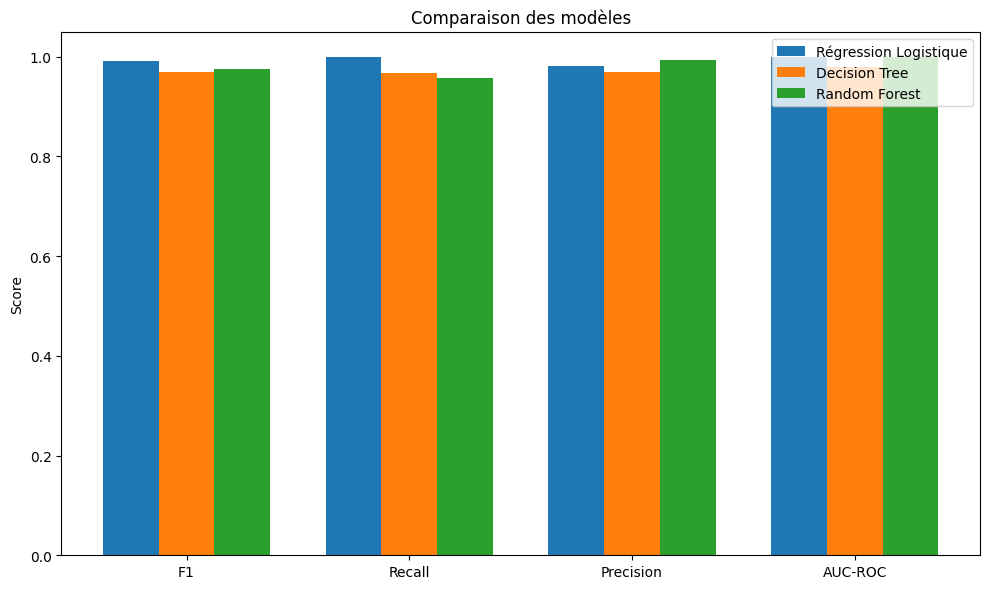

>> 4.2. Visualisation : OK


In [10]:
# 4.2. Visualisation comparative
metriques_plot = ["f1_test", "recall_test", "precision_test", "roc_auc_test"]
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(metriques_plot))
width = 0.25

for i, row in df_resultats.iterrows():
    vals = [row[m] for m in metriques_plot]
    ax.bar(x + i * width, vals, width, label=row["modèle"])

ax.set_xticks(x + width)
ax.set_xticklabels(["F1", "Recall", "Precision", "AUC-ROC"])
ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB3_comparaison_modeles.png", dpi=150)
plt.show()
print(">> 4.2. Visualisation : OK")


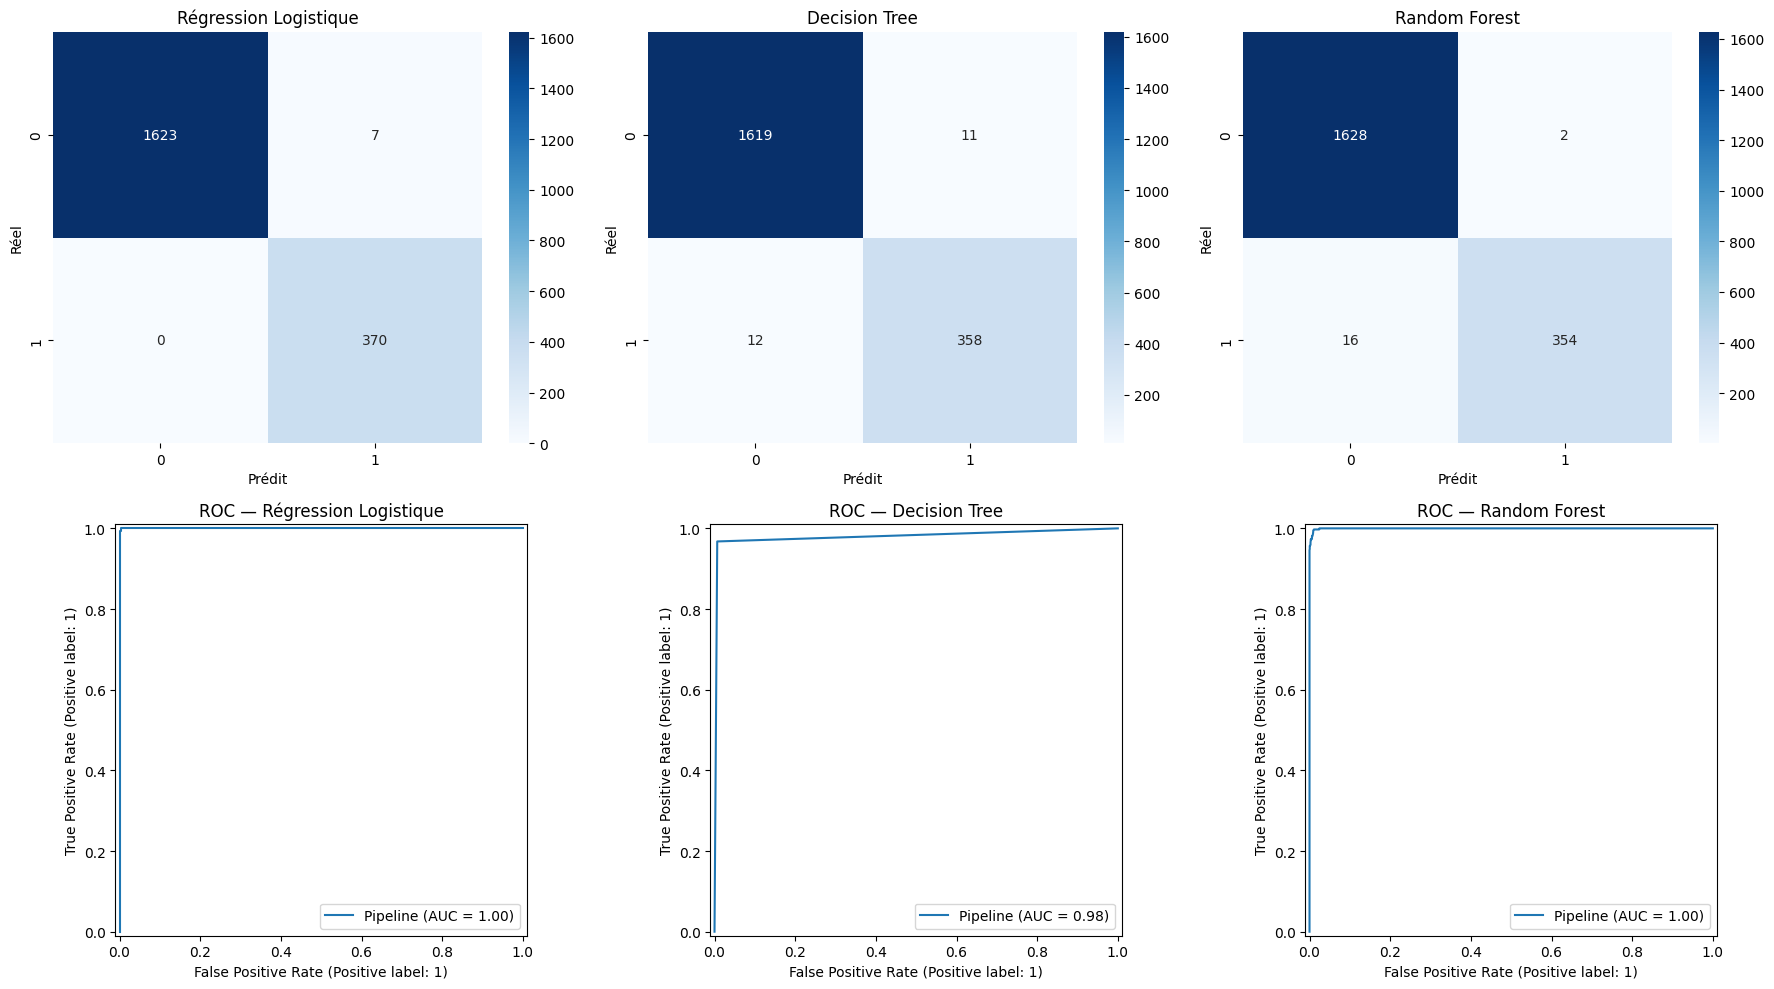

>> 4.3. Confusion + ROC : OK


In [11]:
# 4.3. Matrices de confusion et courbes ROC
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for i, (nom, pipe) in enumerate(pipelines):
    y_pred = pipe.predict(X_test)

    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0, i])
    axes[0, i].set_title(f"{nom}")
    axes[0, i].set_xlabel("Prédit")
    axes[0, i].set_ylabel("Réel")

    # Courbe ROC
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=axes[1, i])
    axes[1, i].set_title(f"ROC — {nom}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "NB3_confusion_et_roc.png", dpi=150)
plt.show()
print(">> 4.3. Confusion + ROC : OK")


---

### 5. Sélection et sauvegarde du meilleur modèle

---


In [12]:
# 5.1. Sélection du meilleur modèle (critère : F1 score)
meilleur_idx = df_resultats["f1_test"].idxmax()
meilleur_nom = df_resultats.loc[meilleur_idx, "modèle"]
meilleur_f1 = df_resultats.loc[meilleur_idx, "f1_test"]
meilleur_pipe = pipelines[meilleur_idx][1]

print(f"Meilleur modèle : {meilleur_nom}")
print(f"F1 test         : {meilleur_f1}")
print()
print("--- Rapport de classification ---")
y_pred_best = meilleur_pipe.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Non-défaut", "Défaut"]))

# Sauvegarde du modèle
joblib.dump(meilleur_pipe, MODEL_DIR / "best_model.joblib")
print(f"Modèle sauvegardé : {MODEL_DIR / 'best_model.joblib'}")
print(">> 5.1. Sélection : OK")


Meilleur modèle : Régression Logistique
F1 test         : 0.9906

--- Rapport de classification ---
              precision    recall  f1-score   support

  Non-défaut       1.00      1.00      1.00      1630
      Défaut       0.98      1.00      0.99       370

    accuracy                           1.00      2000
   macro avg       0.99      1.00      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Modèle sauvegardé : c:\STOCKAGE_XIA\DU SDA\MLOPS-01\Projet Diego\model\best_model.joblib
>> 5.1. Sélection : OK


---
## Conclusion NB3 — Modélisation comparative
---

### Ce qui a été fait dans ce notebook :

| Constat | Preuve | Décision |
|---------|--------|----------|
| [À compléter après exécution] | [Métriques] | [Modèle retenu] |

### Limites :

- Pas de tuning d'hyperparamètres (GridSearchCV) : les modèles sont entraînés avec les paramètres par défaut + class_weight balanced
- Le dataset est très structuré : les performances risquent d'être élevées pour tous les modèles
- Pas de run avec/sans `credit_lines_outstanding` (prévu dans l'EDA mais non implémenté ici)

### Choix retenus pour la suite :

- Le meilleur modèle est sauvegardé dans `model/best_model.joblib`
- Il pourra être chargé par l'application Streamlit (branche `feat/app`)
- Le tracking MLflow sera géré sur la branche `feat/mlflow`
